In [2]:
import os
import zipfile
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Input,
    Embedding
)
from tensorflow.keras.optimizers import Adam

In [2]:
print("TensorFlow version:", tf.__version__)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

TensorFlow version: 2.20.0


In [ ]:
# from google.colab import files
# uploaded = files.upload()

# zip_name = next(
#     filename for filename in uploaded.keys()
#     if filename.endswith(".zip")
# )

# with zipfile.ZipFile(zip_name, "r") as zip_ref:
#     zip_ref.extractall("/content")

# DATASET_PATH = Path("/content/UCI HAR Dataset")

# print("Dataset path:", DATASET_PATH)
# print("Dataset exists:", DATASET_PATH.exists())

# print(os.listdir(DATASET_PATH))
# print("\nTrain folder:")
# print(os.listdir(DATASET_PATH / "train"))

Saving UCI HAR Dataset.zip to UCI HAR Dataset (1).zip
Dataset path: /content/UCI HAR Dataset
Dataset exists: True
['test', 'README.txt', 'activity_labels.txt', '.DS_Store', 'features.txt', 'features_info.txt', 'train']

Train folder:
['y_train.txt', 'Inertial Signals', 'subject_train.txt', 'X_train.txt']


In [3]:
import os
print(os.listdir("/kaggle/input"))
from pathlib import Path

for path in Path("/kaggle/input").rglob("UCI HAR Dataset"):
    print(path)

['datasets']


In [4]:
from pathlib import Path
import os

# Find the UCI HAR Dataset inside Kaggle input
DATASET_PATH = next(
    path for path in Path("/kaggle/input").rglob("UCI HAR Dataset")
    if (path / "train" / "X_train.txt").exists()
)

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())

print(os.listdir(DATASET_PATH))
print("\nTrain folder:")
print(os.listdir(DATASET_PATH / "train"))

Dataset path: /kaggle/input/datasets/srinithia07/uci-har-dataset/UCI HAR Dataset
Dataset exists: True
['activity_labels.txt', 'README.txt', 'features_info.txt', 'features.txt', 'test', 'train']

Train folder:
['X_train.txt', 'Inertial Signals', 'subject_train.txt', 'y_train.txt']


In [5]:
SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

print("Number of channels:", len(SIGNAL_NAMES))
print("Channels:")
for i, name in enumerate(SIGNAL_NAMES, start=1):
    print(i, name)

Number of channels: 9
Channels:
1 body_acc_x
2 body_acc_y
3 body_acc_z
4 body_gyro_x
5 body_gyro_y
6 body_gyro_z
7 total_acc_x
8 total_acc_y
9 total_acc_z


## Preprocessing

In [6]:
def load_raw_signals(folder, split):
    signal_data = []
    for signal_name in SIGNAL_NAMES:
        file_path = (
            folder
            / "Inertial Signals"
            / f"{signal_name}_{split}.txt"
        )
        data = np.loadtxt(file_path)
        print(
            f"{signal_name}_{split}.txt -> {data.shape}"
        )
        signal_data.append(data)

    # 9 arrays of shape (N, 128)
    # Stack along last dimension
    # Result: (N, 128, 9)

    X = np.stack(
        signal_data,
        axis=-1
    )
    return X

In [7]:
# Load the 9 raw inertial signals from the UCI HAR training set
X_all = load_raw_signals(DATASET_PATH / "train", "train")

y_all = np.loadtxt(
    DATASET_PATH / "train" / "y_train.txt",
    dtype=int
)

print("\nComplete training data shape:", X_all.shape)
print("Labels shape:", y_all.shape)
print("Number of classes:", len(np.unique(y_all)))
print("Unique labels:", np.unique(y_all))

body_acc_x_train.txt -> (7352, 128)
body_acc_y_train.txt -> (7352, 128)
body_acc_z_train.txt -> (7352, 128)
body_gyro_x_train.txt -> (7352, 128)
body_gyro_y_train.txt -> (7352, 128)
body_gyro_z_train.txt -> (7352, 128)
total_acc_x_train.txt -> (7352, 128)
total_acc_y_train.txt -> (7352, 128)
total_acc_z_train.txt -> (7352, 128)

Complete training data shape: (7352, 128, 9)
Labels shape: (7352,)
Number of classes: 6
Unique labels: [1 2 3 4 5 6]


In [8]:
SAMPLES_PER_CLASS = 500

selected_indices = []

for class_id in range(1, 7):
    class_indices = np.where(y_all == class_id)[0]
    selected_class_indices = class_indices[:SAMPLES_PER_CLASS]
    selected_indices.extend(selected_class_indices)

selected_indices = np.array(selected_indices)

X = X_all[selected_indices]
y = y_all[selected_indices]

print("Selected data shape:", X.shape)
print("Selected labels shape:", y.shape)

Selected data shape: (3000, 128, 9)
Selected labels shape: (3000,)


In [9]:
activity_names = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

class_counts = pd.Series(y).value_counts().sort_index()

distribution_table = pd.DataFrame({
    "Class ID": range(1, 7),
    "Activity": activity_names,
    "Count": class_counts.values
})

display(distribution_table)

,Class ID,Activity,Count
0,1,WALKING,500
1,2,WALKING UPSTAIRS,500
2,3,WALKING DOWNSTAIRS,500
3,4,SITTING,500
4,5,STANDING,500
5,6,LAYING,500


In [10]:
y = y - 1

print("Unique encoded labels:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

Unique encoded labels: [0 1 2 3 4 5]
Number of classes: 6


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Training shape  :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape   :", X_test.shape)

Training shape  : (2100, 128, 9)
Validation shape: (450, 128, 9)
Testing shape   : (450, 128, 9)


In [12]:
#normalize
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True)

train_std = np.where(train_std == 0, 1, train_std)

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Normalization completed.")
print("Training mean:", X_train.mean())
print("Training std :", X_train.std())

Normalization completed.
Training mean: 3.691932121570957e-17
Training std : 1.0000000000000038


In [13]:
print("Input tensor shape:")
print("Training  :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing   :", X_test.shape)

print("\nNumber of classes:", len(np.unique(y_train)))
print("Features per time step:", X_train.shape[2])
print("Sequence length:", X_train.shape[1])

Input tensor shape:
Training  : (2100, 128, 9)
Validation: (450, 128, 9)
Testing   : (450, 128, 9)

Number of classes: 6
Features per time step: 9
Sequence length: 128


## Data Visualization

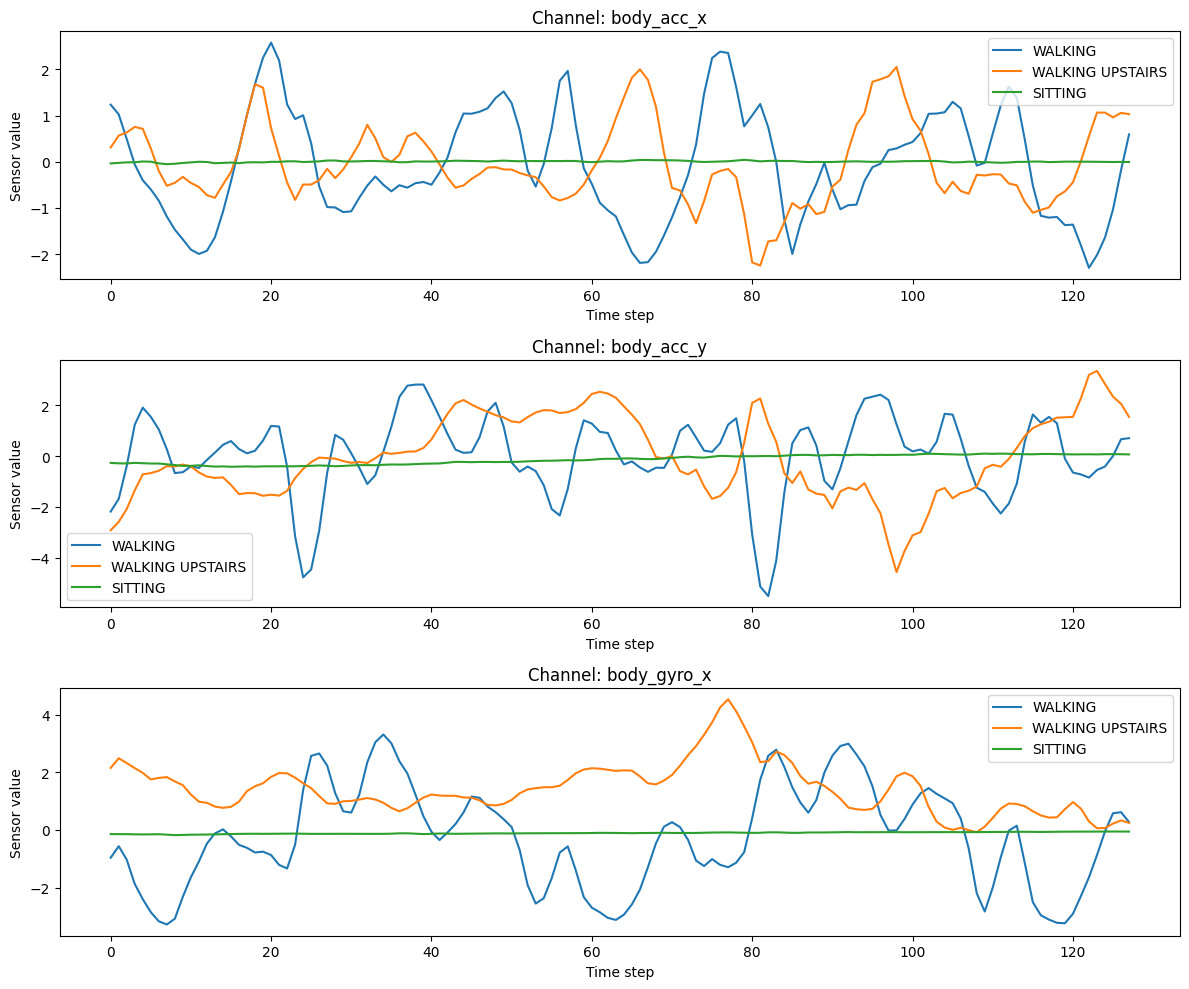

In [14]:
# Select one representative sample from three different classes

classes_to_plot = [0, 1, 3]
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
channels_to_plot = [0, 1, 3]

for row, channel in enumerate(channels_to_plot):
    for class_id in classes_to_plot:
        indices = np.where(y_train == class_id)[0]
        sample_index = indices[0]
        axes[row].plot(
            X_train[sample_index, :, channel],
            label=activity_names[class_id]
        )

    axes[row].set_xlabel("Time step")
    axes[row].set_ylabel("Sensor value")
    axes[row].set_title(
        f"Channel: {SIGNAL_NAMES[channel]}"
    )
    axes[row].legend()

plt.tight_layout()
plt.show()

In [15]:
#BPTT exercise
x_values = [0.5, 0.7, 0.2]
h = 0.0
Wx = 0.5
Wh = 0.8
b = 0.1
hidden_states = []
for t, x_t in enumerate(x_values, 1):
    h = np.tanh(Wx * x_t + Wh * h + b)
    hidden_states.append(h)
    print(f"h{t} = {h:.6f}")

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


In [16]:
def build_model(recurrent_type, sequence_length=128):
    model = Sequential()

    if recurrent_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(sequence_length, 9)))

    elif recurrent_type == "LSTM":
        model.add(LSTM(32, input_shape=(sequence_length, 9)))

    elif recurrent_type == "GRU":
        model.add(GRU(32, input_shape=(sequence_length, 9)))

    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(6, activation="softmax"))

    model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [17]:
def train_and_evaluate(model_name, recurrent_type, X_train, y_train,
                       X_val, y_val, X_test, y_test,
                       sequence_length=128, epochs=30):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    model = build_model(recurrent_type, sequence_length)
    model.summary()

    parameter_count = model.count_params()
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        verbose=1
    )

    training_time = time.time() - start_time

    probabilities = model.predict(
        X_test,
        batch_size=32,
        verbose=0
    )

    predictions = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_test, predictions,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_test, predictions,
        average="macro",
        zero_division=0
    )

    result = {
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Macro Precision (%)": precision * 100,
        "Macro Recall (%)": recall * 100,
        "Macro F1 (%)": f1 * 100,
        "Parameters": parameter_count,
        "Training Time (s)": training_time
    }

    return model, history, predictions, probabilities, result

##RNN

In [18]:
rnn_model, rnn_history, rnn_predictions, rnn_probabilities, rnn_result = train_and_evaluate(
    "RNN", "RNN",
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

print("\nRNN results:")
print(rnn_result)

RNN


I0000 00:00:1790148357.211448      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790148357.214693      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
19/66 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2019 - loss: 1.9331

I0000 00:00:1790148362.111115     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3686 - loss: 1.6468 - val_accuracy: 0.4867 - val_loss: 1.3481
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4895 - loss: 1.2833 - val_accuracy: 0.5267 - val_loss: 1.1691
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5495 - loss: 1.1075 - val_accuracy: 0.5556 - val_loss: 1.0376
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5410 - loss: 1.0689 - val_accuracy: 0.5844 - val_loss: 0.9480
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6281 - loss: 0.8847 - val_accuracy: 0.6022 - val_loss: 0.8609
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6557 - loss: 0.7881 - val_accuracy: 0.6333 - val_loss: 0.7949
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5790 - loss: 0.9571 - val_accuracy: 0.5756 - val_loss: 0.9178
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6086 - loss: 0.8754 - val_accuracy: 0.5911 - val_loss: 0.

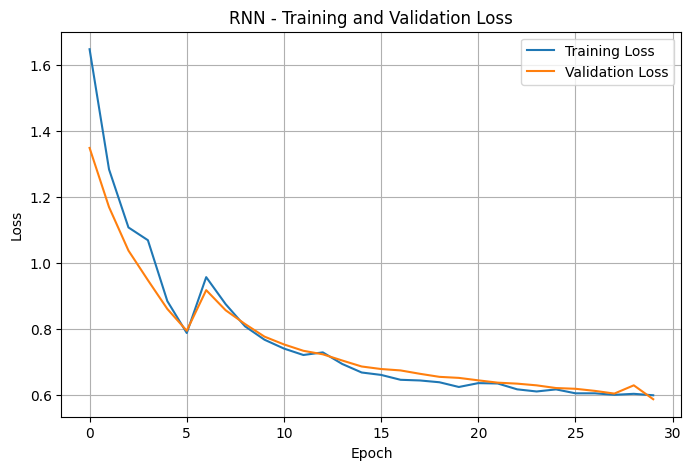

In [19]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

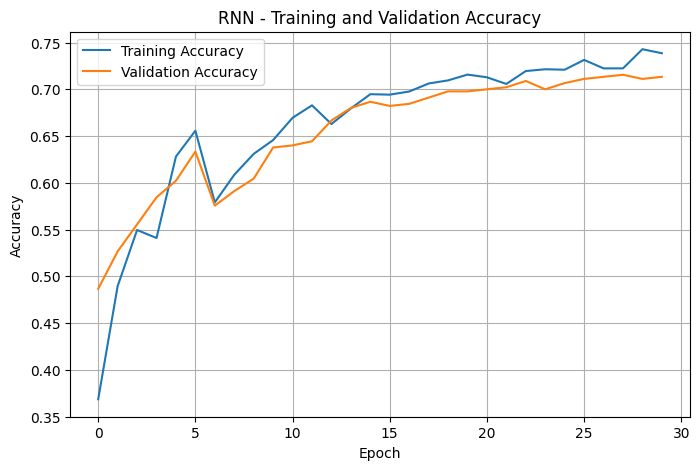

In [20]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

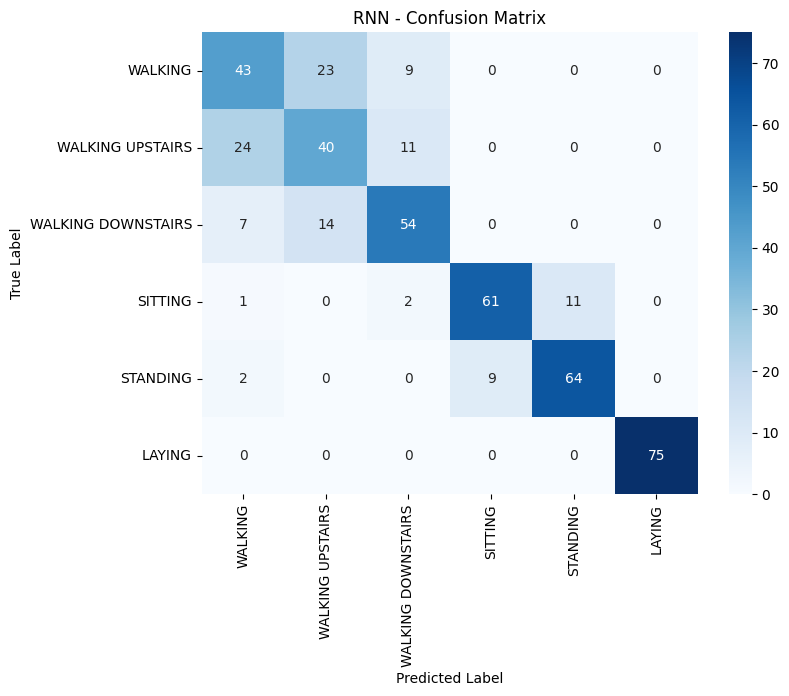

In [21]:
rnn_cm = confusion_matrix(y_test, rnn_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(rnn_cm, annot=True, fmt="d", cmap="Blues", xticklabels=activity_names, yticklabels=activity_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RNN - Confusion Matrix")
plt.show()

##LSTM

In [22]:
lstm_model, lstm_history, lstm_predictions, lstm_probabilities, lstm_result = train_and_evaluate(
    "LSTM", "LSTM",
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

print("\nLSTM results:")
print(lstm_result)


LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4052 - loss: 1.5321 - val_accuracy: 0.5222 - val_loss: 1.1650
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6114 - loss: 0.9690 - val_accuracy: 0.6689 - val_loss: 0.8386
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6881 - loss: 0.7543 - val_accuracy: 0.6844 - val_loss: 0.7038
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7024 - loss: 0.6748 - val_accuracy: 0.7200 - val_loss: 0.6440
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7581 - loss: 0.5802 - val_accuracy: 0.7978 - val_loss: 0.5272
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7995 - loss: 0.4614 - val_accuracy: 0.8156 - val_loss: 0.4312
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8176 - loss: 0.3889 - val_accuracy: 0.8311 - val_loss: 0.3859
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8338 - loss: 0.3649 - val_accuracy: 0.8200 - val_los

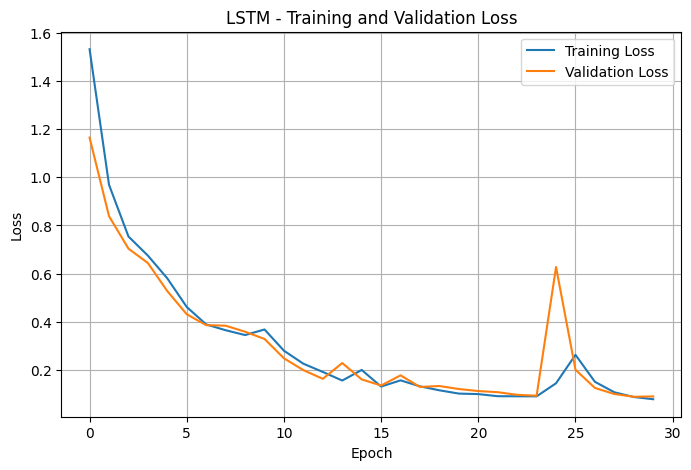

In [23]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

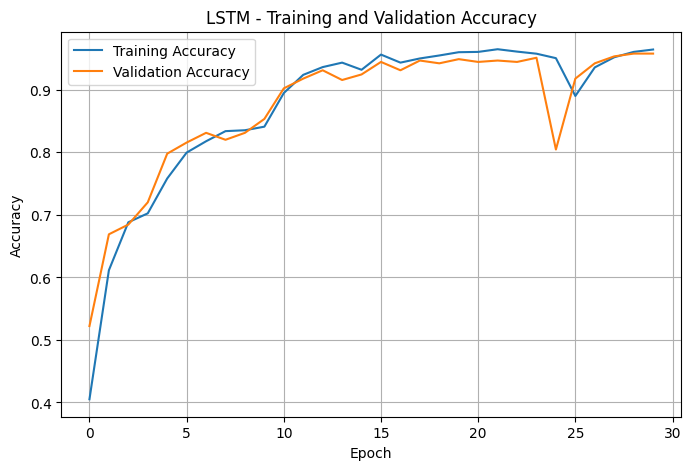

In [24]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

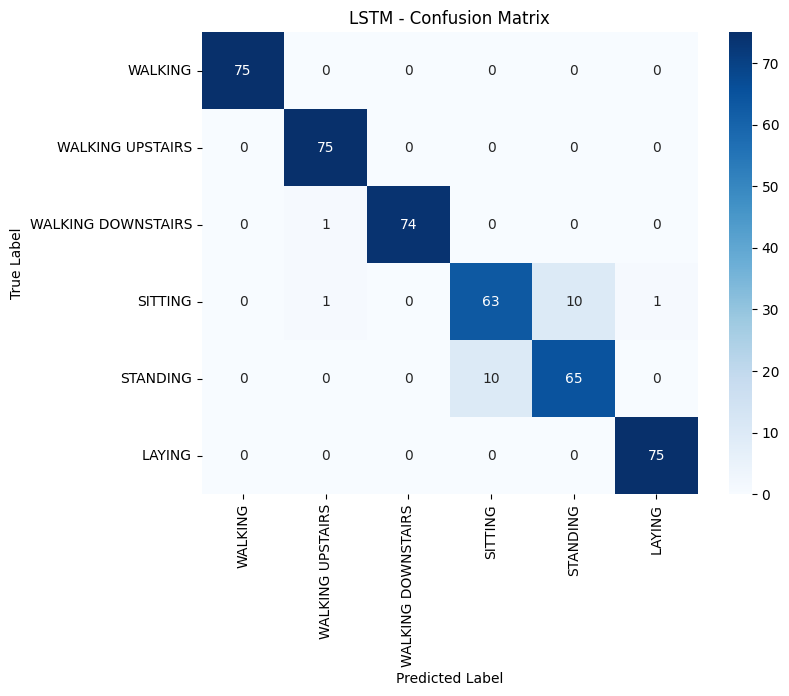

In [25]:
lstm_cm = confusion_matrix(y_test, lstm_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(lstm_cm, annot=True, fmt="d", cmap="Blues", xticklabels=activity_names, yticklabels=activity_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM - Confusion Matrix")
plt.show()

##GRU

In [26]:
gru_model, gru_history, gru_predictions, gru_probabilities, gru_result = train_and_evaluate(
    "GRU", "GRU",
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

print("\nGRU results:")
print(gru_result)

GRU


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4733 - loss: 1.5140 - val_accuracy: 0.5711 - val_loss: 1.2558
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5671 - loss: 1.0985 - val_accuracy: 0.6844 - val_loss: 0.8440
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6857 - loss: 0.7525 - val_accuracy: 0.7067 - val_loss: 0.6556
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7333 - loss: 0.6197 - val_accuracy: 0.7600 - val_loss: 0.5865
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7752 - loss: 0.5508 - val_accuracy: 0.8222 - val_loss: 0.4934
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8381 - loss: 0.4406 - val_accuracy: 0.8778 - val_loss: 0.3540
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8957 - loss: 0.3106 - val_accuracy: 0.9178 - val_loss: 0.2619
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9190 - loss: 0.2374 - val_accuracy: 0.9422 - val_

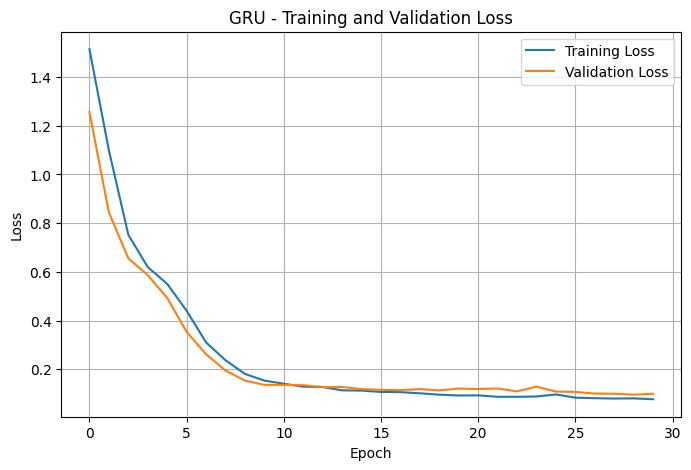

In [27]:
plt.figure(figsize=(8,5))
plt.plot(gru_history.history["loss"], label="Training Loss")
plt.plot(gru_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

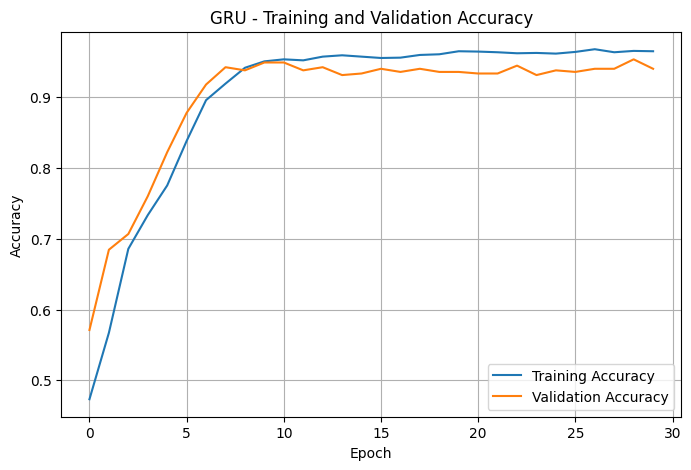

In [28]:
plt.figure(figsize=(8,5))
plt.plot(gru_history.history["accuracy"], label="Training Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

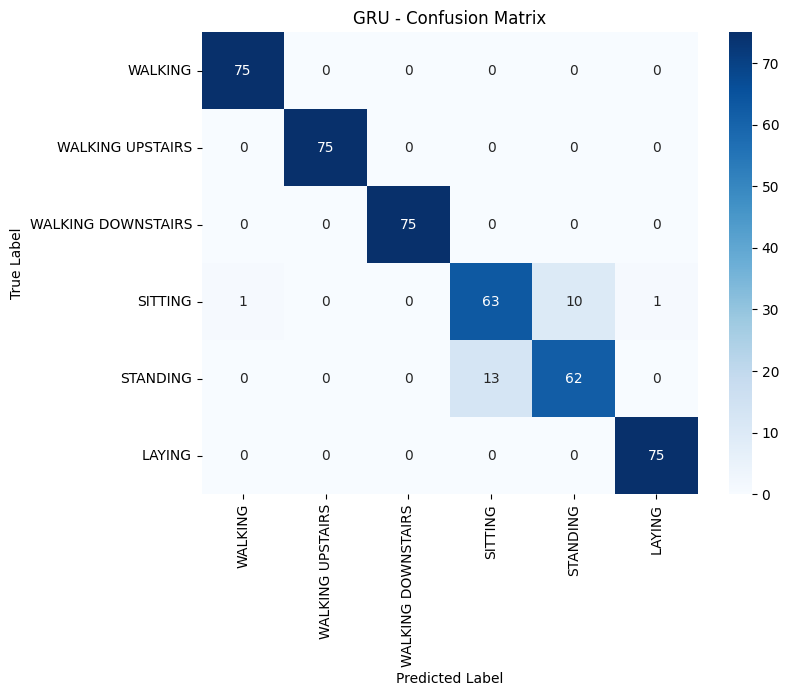

In [29]:
gru_cm = confusion_matrix(y_test, gru_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(gru_cm, annot=True, fmt="d", cmap="Blues", xticklabels=activity_names, yticklabels=activity_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("GRU - Confusion Matrix")
plt.show()

##Results

In [30]:
results_df = pd.DataFrame([rnn_result, lstm_result, gru_result])
display(results_df)

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,74.888889,75.220172,74.888889,75.034162,1974,27.484096
1,LSTM,94.888889,94.842474,94.888889,94.858770,6006,23.666789
2,GRU,94.444444,94.395712,94.444444,94.412158,4758,21.123605


In [31]:
architecture_comparison = pd.DataFrame({
    "Property": [
        "Hidden state",
        "Cell state",
        "Forget gate",
        "Input gate",
        "Output gate",
        "Update gate",
        "Reset gate",
        "Parameters",
        "Training time",
        "Test F1-score"
    ],
    "RNN": [
        "Yes", "No", "No", "No", "No", "No", "No",
        rnn_result["Parameters"],
        rnn_result["Training Time (s)"],
        rnn_result["Macro F1 (%)"]
    ],
    "LSTM": [
        "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
        lstm_result["Parameters"],
        lstm_result["Training Time (s)"],
        lstm_result["Macro F1 (%)"]
    ],
    "GRU": [
        "Yes", "No", "No", "No", "No", "Yes", "Yes",
        gru_result["Parameters"],
        gru_result["Training Time (s)"],
        gru_result["Macro F1 (%)"]
    ]
})

display(architecture_comparison)

,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time,27.484096,23.666789,21.123605
9,Test F1-score,75.034162,94.85877,94.412158


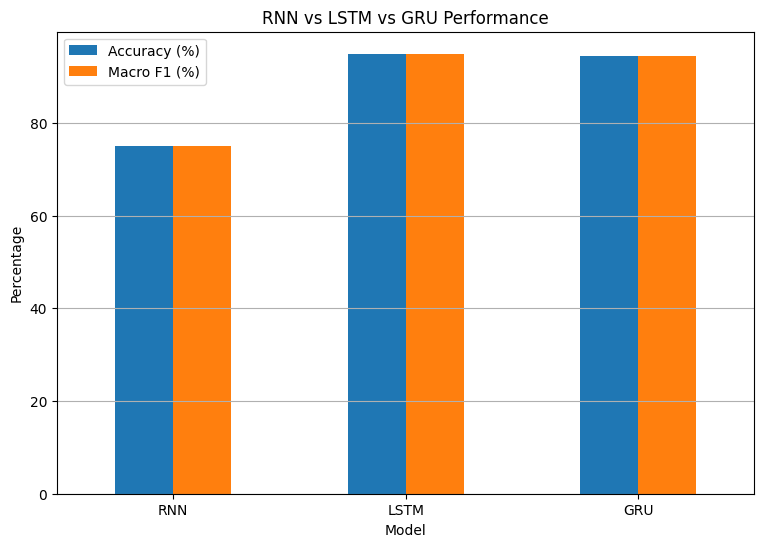

In [32]:
results_df.set_index("Model")[["Accuracy (%)","Macro F1 (%)"]].plot(kind="bar", figsize=(9,6))
plt.xlabel("Model")
plt.ylabel("Percentage")
plt.title("RNN vs LSTM vs GRU Performance")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [33]:
def confusion_analysis(cm, model_name):

    correct = np.diag(cm)
    total = cm.sum(axis=1)
    recognition_rate = correct / total
    errors = total - correct

    print(f"\n{model_name}")
    print("-" * 40)
    print("Highest recognition rate:", activity_names[np.argmax(recognition_rate)], f"({recognition_rate.max()*100:.2f}%)")
    print("Largest number of errors:", activity_names[np.argmax(errors)], f"({errors.max()})")
    print("\nConfused activity pairs:")
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)
    max_error = cm_copy.max()

    for i, j in np.argwhere(cm_copy == max_error):
        print(f"{activity_names[i]} -> {activity_names[j]} : {cm[i,j]}")

confusion_analysis(rnn_cm, "RNN")
confusion_analysis(lstm_cm, "LSTM")
confusion_analysis(gru_cm, "GRU")


RNN
----------------------------------------
Highest recognition rate: LAYING (100.00%)
Largest number of errors: WALKING UPSTAIRS (35)

Confused activity pairs:
WALKING UPSTAIRS -> WALKING : 24

LSTM
----------------------------------------
Highest recognition rate: WALKING (100.00%)
Largest number of errors: SITTING (12)

Confused activity pairs:
SITTING -> STANDING : 10
STANDING -> SITTING : 10

GRU
----------------------------------------
Highest recognition rate: WALKING (100.00%)
Largest number of errors: STANDING (13)

Confused activity pairs:
STANDING -> SITTING : 13


##Effect of sequence length

In [34]:
sequence_lengths = [32, 64, 128]
sequence_length_results = []

for seq_len in sequence_lengths:
    print("\n" + "=" * 60)
    print(f"SEQUENCE LENGTH = {seq_len}")
    print("=" * 60)

    X_train_seq = X_train[:, :seq_len, :]
    X_val_seq = X_val[:, :seq_len, :]
    X_test_seq = X_test[:, :seq_len, :]

    for model_name in ["RNN", "LSTM", "GRU"]:
        model, history, predictions, probabilities, result = train_and_evaluate(
            f"{model_name} - T={seq_len}",
            model_name,
            X_train_seq, y_train,
            X_val_seq, y_val,
            X_test_seq, y_test,
            sequence_length=seq_len,
            epochs=30
        )

        sequence_length_results.append({
            "Sequence Length": seq_len,
            "Model": model_name,
            "Test Accuracy (%)": result["Accuracy (%)"],
            "Test F1 (%)": result["Macro F1 (%)"],
            "Parameters": result["Parameters"],
            "Training Time (s)": result["Training Time (s)"]
        })


SEQUENCE LENGTH = 32
RNN - T=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3752 - loss: 1.6491 - val_accuracy: 0.5511 - val_loss: 1.4389
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5738 - loss: 1.2593 - val_accuracy: 0.5978 - val_loss: 1.0638
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6410 - loss: 0.9300 - val_accuracy: 0.6822 - val_loss: 0.8031
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7295 - loss: 0.7033 - val_accuracy: 0.7956 - val_loss: 0.6171
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8210 - loss: 0.5227 - val_accuracy: 0.8822 - val_loss: 0.4354
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8867 - loss: 0.3638 - val_accuracy: 0.9000 - val_loss: 0.2872
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9310 - loss: 0.2336 - val_accuracy: 0.9178 - val_loss: 0.1968
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9443 - loss: 0.1695 - val_accuracy: 0.9533 - val

In [35]:
sequence_results_df = pd.DataFrame(sequence_length_results)

display(sequence_results_df)

,Sequence Length,Model,Test Accuracy (%),Test F1 (%),Parameters,Training Time (s)
0,32,RNN,88.222222,88.134292,1974,17.591311
1,32,LSTM,95.555556,95.537698,6006,16.846129
2,32,GRU,93.333333,93.350453,4758,16.464795
3,64,RNN,86.000000,86.032657,1974,20.087051
4,64,LSTM,94.444444,94.425978,6006,18.341986
5,64,GRU,94.444444,94.428029,4758,18.488919
6,128,RNN,70.222222,69.946173,1974,26.646211
7,128,LSTM,95.777778,95.777590,6006,21.414137
8,128,GRU,94.888889,94.872044,4758,21.225366


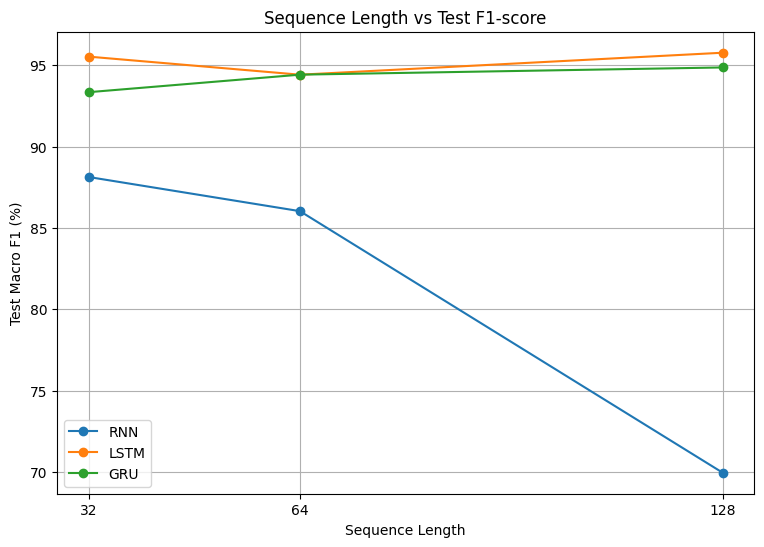

In [36]:
plt.figure(figsize=(9,6))
for model_name in ["RNN","LSTM","GRU"]:
    data = sequence_results_df[sequence_results_df["Model"] == model_name]
    plt.plot(data["Sequence Length"], data["Test F1 (%)"], marker="o", label=model_name)
plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1 (%)")
plt.title("Sequence Length vs Test F1-score")
plt.xticks(sequence_lengths)
plt.legend()
plt.grid(True)
plt.show()

##Video Processing

In [37]:
from pathlib import Path

for path in Path("/kaggle/input").iterdir():
    print(path)

/kaggle/input/datasets


In [38]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

CLASS_NAMES = ["Biking", "TennisSwing", "WalkingWithDog"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

for class_name in CLASS_NAMES:
    matches = list(INPUT_ROOT.rglob(class_name))
    print(f"{class_name}:")
    for m in matches[:5]:
        print(" ", m)

Biking:
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val/Biking
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/Biking
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/Biking
TennisSwing:
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val/TennisSwing
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/TennisSwing
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/TennisSwing
WalkingWithDog:
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val/WalkingWithDog
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/WalkingWithDog
  /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/WalkingWithDog


In [39]:
UCF_ROOT = Path("/kaggle/input/datasets/matthewjansen/ucf101-action-recognition")

CLASS_NAMES = ["Biking", "TennisSwing", "WalkingWithDog"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

print(CLASS_TO_ID)

for class_name in CLASS_NAMES:
    for split in ["train", "val", "test"]:
        class_path = UCF_ROOT / split / class_name
        print(class_name, split, "->", class_path.exists(), "videos:", len(list(class_path.glob("*.avi"))))

{'Biking': 0, 'TennisSwing': 1, 'WalkingWithDog': 2}
Biking train -> True videos: 100
Biking val -> True videos: 17
Biking test -> True videos: 17
TennisSwing train -> True videos: 124
TennisSwing val -> True videos: 21
TennisSwing test -> True videos: 21
WalkingWithDog train -> True videos: 92
WalkingWithDog val -> True videos: 15
WalkingWithDog test -> True videos: 16


In [40]:
VIDEOS_PER_CLASS = 20

video_records = []

for split in ["train", "val", "test"]:
    for class_name in CLASS_NAMES:
        class_path = UCF_ROOT / split / class_name
        video_files = sorted(class_path.glob("*.avi"))[:VIDEOS_PER_CLASS]

        for video_path in video_files:
            video_records.append({
                "path": str(video_path),
                "class_name": class_name,
                "label": CLASS_TO_ID[class_name],
                "split": split
            })

video_df = pd.DataFrame(video_records)

print("Total videos:", len(video_df))
print(video_df["split"].value_counts())
print(video_df["class_name"].value_counts())

Total videos: 165
split
train    60
test     53
val      52
Name: count, dtype: int64
class_name
TennisSwing       60
Biking            54
WalkingWithDog    51
Name: count, dtype: int64


In [41]:
train_df = video_df[video_df["split"] == "train"].reset_index(drop=True)
val_df = video_df[video_df["split"] == "val"].reset_index(drop=True)
test_df = video_df[video_df["split"] == "test"].reset_index(drop=True)

print("Training videos:", len(train_df))
print("Validation videos:", len(val_df))
print("Testing videos:", len(test_df))

print("\nTraining distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTesting distribution:")
print(test_df["class_name"].value_counts())

Training videos: 60
Validation videos: 52
Testing videos: 53

Training distribution:
class_name
Biking            20
TennisSwing       20
WalkingWithDog    20
Name: count, dtype: int64

Validation distribution:
class_name
TennisSwing       20
Biking            17
WalkingWithDog    15
Name: count, dtype: int64

Testing distribution:
class_name
TennisSwing       20
Biking            17
WalkingWithDog    16
Name: count, dtype: int64


In [42]:
IMG_SIZE = (224, 224)
NUM_FRAMES = 10

def read_uniform_frames(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0, total_frames - 1, num_frames
    ).astype(int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, IMG_SIZE)
            frames.append(frame)

    cap.release()

    if len(frames) != num_frames:
        return None

    return np.array(frames)

In [43]:
import cv2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

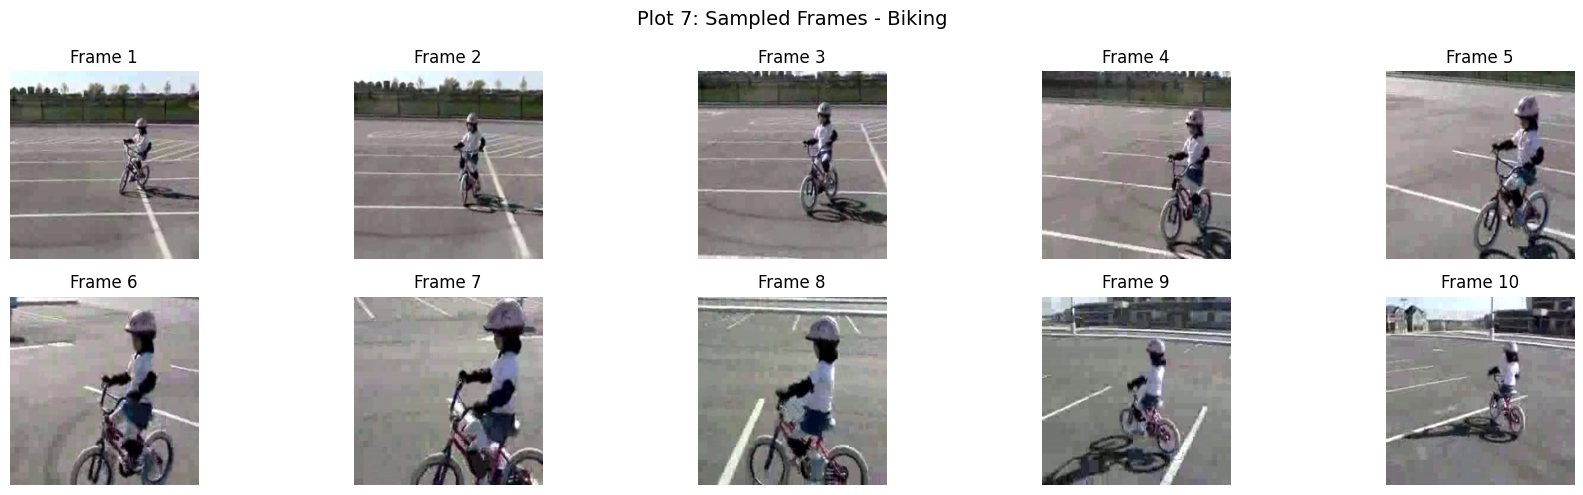

In [44]:
sample_video = train_df.iloc[0]["path"]

sampled_frames = read_uniform_frames(sample_video, NUM_FRAMES)

plt.figure(figsize=(18, 5))

for i, frame in enumerate(sampled_frames):
    plt.subplot(2, 5, i + 1)
    plt.imshow(frame)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.suptitle(
    f"Plot 7: Sampled Frames - {train_df.iloc[0]['class_name']}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [45]:
#pre trained mobilenet model
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

cnn.trainable = False

print("CNN feature dimension:", cnn.output_shape[-1])
print("Trainable parameters:", sum(np.prod(v.shape) for v in cnn.trainable_weights))
print("Total parameters:", cnn.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension: 1280
Trainable parameters: 0
Total parameters: 2257984


In [46]:
#extract cnn features
def extract_video_features(video_dataframe, cnn_model):
    all_features = []
    all_labels = []
    valid_paths = []

    for _, row in video_dataframe.iterrows():
        frames = read_uniform_frames(row["path"], NUM_FRAMES)

        if frames is None or len(frames) != NUM_FRAMES:
            print("Skipping:", row["path"])
            continue

        frames_preprocessed = preprocess_input(frames.astype(np.float32))
        features = cnn_model.predict(frames_preprocessed, verbose=0)

        all_features.append(features)
        all_labels.append(row["label"])
        valid_paths.append(row["path"])

    return np.array(all_features), np.array(all_labels), valid_paths

In [47]:
start_time = time.time()

X_video_train, y_video_train, train_paths = extract_video_features(train_df, cnn)
X_video_val, y_video_val, val_paths = extract_video_features(val_df, cnn)
X_video_test, y_video_test, test_paths = extract_video_features(test_df, cnn)

feature_extraction_time = time.time() - start_time

print("Feature extraction time:", feature_extraction_time, "seconds")

print("Training tensor:", X_video_train.shape)
print("Validation tensor:", X_video_val.shape)
print("Testing tensor:", X_video_test.shape)

2026-09-23 07:30:45.758195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 07:30:45.895316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Skipping: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val/WalkingWithDog/v_WalkingWithDog_g06_c05.avi
Skipping: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/WalkingWithDog/v_WalkingWithDog_g12_c03.avi
Skipping: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test/WalkingWithDog/v_WalkingWithDog_g13_c05.avi
Feature extraction time: 34.801297426223755 seconds
Training tensor: (60, 10, 1280)
Validation tensor: (51, 10, 1280)
Testing tensor: (51, 10, 1280)


In [48]:
video_model = Sequential([
    LSTM(32, input_shape=(NUM_FRAMES, X_video_train.shape[2])),
    Dense(len(CLASS_NAMES), activation="softmax")
])

video_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

video_model.summary()
print("Trainable parameters:", video_model.count_params())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,163 (656.89 KB)

 Trainable params: 168,163 (656.89 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 168163


In [49]:
start_time = time.time()

video_history = video_model.fit(
    X_video_train,
    y_video_train,
    validation_data=(X_video_val, y_video_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

video_training_time = time.time() - start_time
print("Video model training time:", video_training_time, "seconds")

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6500 - loss: 0.9838 - val_accuracy: 0.7059 - val_loss: 0.7850
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9667 - loss: 0.3952 - val_accuracy: 0.8235 - val_loss: 0.4840
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9833 - loss: 0.2193 - val_accuracy: 0.8824 - val_loss: 0.3899
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1245 - val_accuracy: 0.9412 - val_loss: 0.2753
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9833 - loss: 0.0732 - val_accuracy: 0.9216 - val_loss: 0.2033
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0472 - val_accuracy: 0.9020 - val_loss: 0.2930
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0382 - val_accuracy: 0.8627 - val_loss: 0.3355
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0287 - val_accuracy: 0.8824 - val_loss: 0.2653


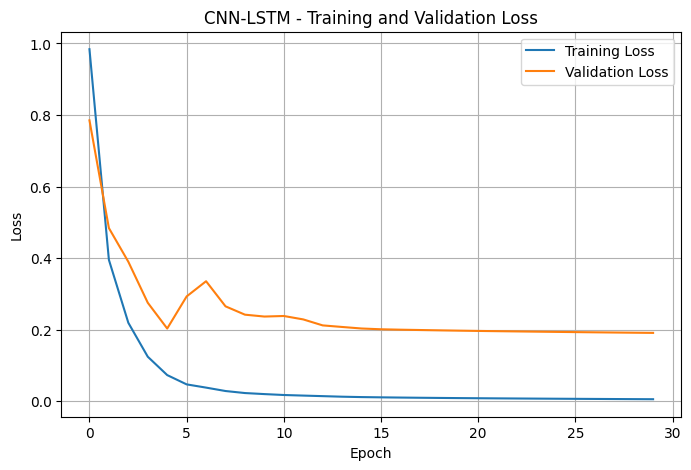

In [50]:
plt.figure(figsize=(8,5))
plt.plot(video_history.history["loss"], label="Training Loss")
plt.plot(video_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

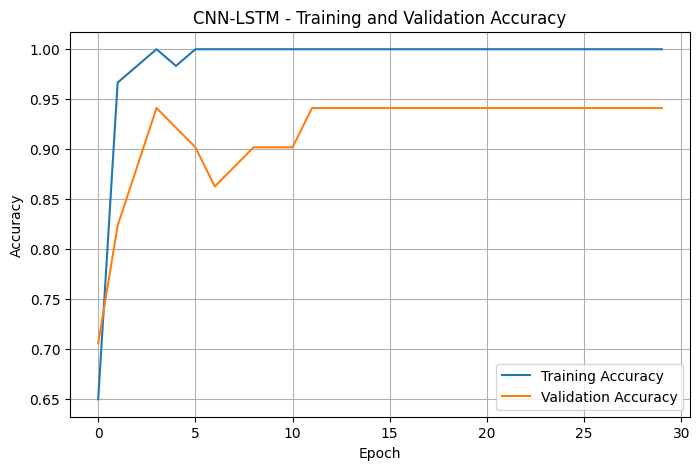

In [51]:
plt.figure(figsize=(8,5))
plt.plot(video_history.history["accuracy"], label="Training Accuracy")
plt.plot(video_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
video_probabilities = video_model.predict(X_video_test, verbose=0)
video_predictions = np.argmax(video_probabilities, axis=1)

video_accuracy = accuracy_score(y_video_test, video_predictions)
video_precision = precision_score(y_video_test, video_predictions, average="macro", zero_division=0)
video_recall = recall_score(y_video_test, video_predictions, average="macro", zero_division=0)
video_f1 = f1_score(y_video_test, video_predictions, average="macro", zero_division=0)

print("CNN-LSTM Test Accuracy:", video_accuracy * 100)
print("CNN-LSTM Macro Precision:", video_precision * 100)
print("CNN-LSTM Macro Recall:", video_recall * 100)
print("CNN-LSTM Macro F1:", video_f1 * 100)

print("Parameters:", video_model.count_params())
print("Training time (s):", video_training_time)

CNN-LSTM Test Accuracy: 92.15686274509804
CNN-LSTM Macro Precision: 91.66666666666666
CNN-LSTM Macro Recall: 92.03081232492997
CNN-LSTM Macro F1: 91.67055167055166
Parameters: 168163
Training time (s): 6.072739124298096


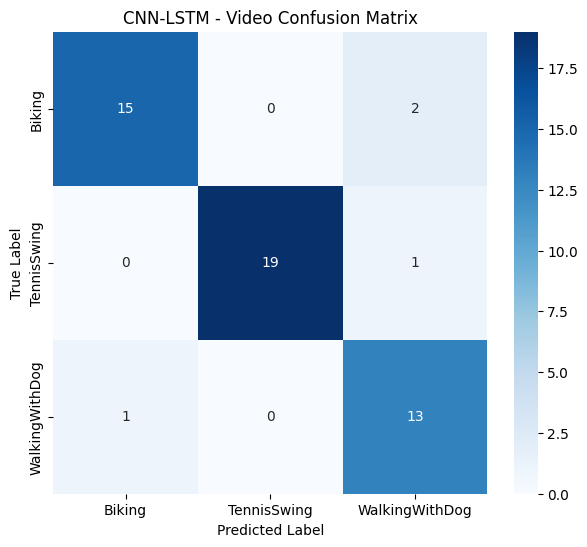

In [53]:
video_cm = confusion_matrix(y_video_test, video_predictions)

plt.figure(figsize=(7,6))
sns.heatmap(video_cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN-LSTM - Video Confusion Matrix")
plt.show()

In [54]:
for i in range(min(5, len(test_paths))):
    predicted_id = video_predictions[i]
    actual_id = y_video_test[i]
    confidence = video_probabilities[i][predicted_id]
    print(f"Video: {Path(test_paths[i]).name}")
    print(f"Predicted class: {CLASS_NAMES[predicted_id]}")
    print(f"Actual class: {CLASS_NAMES[actual_id]}")
    print(f"Confidence: {confidence:.4f}")
    print()

Video: v_Biking_g02_c01.avi
Predicted class: Biking
Actual class: Biking
Confidence: 0.9951

Video: v_Biking_g05_c03.avi
Predicted class: Biking
Actual class: Biking
Confidence: 0.9951

Video: v_Biking_g06_c01.avi
Predicted class: Biking
Actual class: Biking
Confidence: 0.9935

Video: v_Biking_g06_c02.avi
Predicted class: Biking
Actual class: Biking
Confidence: 0.9953

Video: v_Biking_g07_c02.avi
Predicted class: Biking
Actual class: Biking
Confidence: 0.9344



In [55]:
video_results = pd.DataFrame([{
    "Model": "CNN-LSTM",
    "Accuracy (%)": video_accuracy * 100,
    "Macro Precision (%)": video_precision * 100,
    "Macro Recall (%)": video_recall * 100,
    "Macro F1 (%)": video_f1 * 100,
    "Parameters": video_model.count_params(),
    "Training Time (s)": video_training_time,
    "CNN Feature Dimension": X_video_train.shape[2],
    "Input Shape": str(X_video_train.shape)
}])

display(video_results)

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s),CNN Feature Dimension,Input Shape
0,CNN-LSTM,92.156863,91.666667,92.030812,91.670552,168163,6.072739,1280,"(60, 10, 1280)"


##Seq-Seq processing

In [3]:
SEQ_LEN = 4
VOCAB_SIZE = 10
NUM_SAMPLES = 5000

np.random.seed(42)

seq2seq_X = np.random.randint(
    1,
    VOCAB_SIZE + 1,
    size=(NUM_SAMPLES, SEQ_LEN)
)

seq2seq_y = np.flip(seq2seq_X, axis=1)

print("Input shape:", seq2seq_X.shape)
print("Output shape:", seq2seq_y.shape)

print("\nExample:")
print("Input :", seq2seq_X[0])
print("Output:", seq2seq_y[0])


X_seq_train, X_seq_temp, y_seq_train, y_seq_temp = train_test_split(
    seq2seq_X,
    seq2seq_y,
    test_size=0.30,
    random_state=42
)

X_seq_val, X_seq_test, y_seq_val, y_seq_test = train_test_split(
    X_seq_temp,
    y_seq_temp,
    test_size=0.50,
    random_state=42
)

print("Training:", X_seq_train.shape)
print("Validation:", X_seq_val.shape)
print("Testing:", X_seq_test.shape)


START_TOKEN = 0

def create_decoder_input(y):
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:] = y[:, :-1]
    return decoder_input

decoder_train = create_decoder_input(y_seq_train)
decoder_val = create_decoder_input(y_seq_val)
decoder_test = create_decoder_input(y_seq_test)

print("Target :", y_seq_train[0])
print("Decoder:", decoder_train[0])

Input shape: (5000, 4)
Output shape: (5000, 4)

Example:
Input : [7 4 8 5]
Output: [5 8 4 7]
Training: (3500, 4)
Validation: (750, 4)
Testing: (750, 4)
Target : [10  2  3 10]
Decoder: [ 0 10  2  3]


In [5]:
SEQ_UNITS = 64

# -----------------------------
# Encoder
# -----------------------------

encoder_inputs = Input(shape=(SEQ_LEN,))

encoder_embedding_layer = Embedding(
    VOCAB_SIZE + 1,
    SEQ_UNITS
)

encoder_embedding = encoder_embedding_layer(
    encoder_inputs
)

encoder_lstm = LSTM(
    SEQ_UNITS,
    return_state=True
)

_, state_h, state_c = encoder_lstm(
    encoder_embedding
)


# -----------------------------
# Decoder
# -----------------------------

decoder_inputs = Input(shape=(SEQ_LEN,))

decoder_embedding_layer = Embedding(
    VOCAB_SIZE + 1,
    SEQ_UNITS
)

decoder_embedding = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    SEQ_UNITS,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=[state_h, state_c]
)


# -----------------------------
# Output layer
# -----------------------------

decoder_dense = Dense(
    VOCAB_SIZE + 1,
    activation="softmax"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)


# -----------------------------
# Complete Seq2Seq model
# -----------------------------

seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 4, 64)     │        704 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 4, 64)     │        704 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 64),      │     33,024 │ embedding_2[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 4, 64),   │     33,024 │ embedding_3[0][0… │
│                     │ (None, 64),       │            │ lstm_2[0][1],     │
│                     │ (None, 64)]       │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4, 11)     │        715 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,171 (266.29 KB)

 Trainable params: 68,171 (266.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# -----------------------------
# Training
# -----------------------------

start_time = time.time()

seq2seq_history = seq2seq_model.fit(
    [X_seq_train, decoder_train],
    y_seq_train[..., np.newaxis],
    validation_data=(
        [X_seq_val, decoder_val],
        y_seq_val[..., np.newaxis]
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

seq2seq_training_time = time.time() - start_time

print(
    "Training time:",
    seq2seq_training_time,
    "seconds"
)


Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3381 - loss: 1.8512 - val_accuracy: 0.5013 - val_loss: 1.2158
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8124 - loss: 0.6444 - val_accuracy: 0.9700 - val_loss: 0.2684
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9909 - loss: 0.1593 - val_accuracy: 0.9957 - val_loss: 0.1094
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0744 - val_accuracy: 0.9993 - val_loss: 0.0583
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9994 - loss: 0.0451 - val_accuracy: 0.9997 - val_loss: 0.0395
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0298 - val_accuracy: 1.0000 - val_loss: 0.0262
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.0225
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0174 - val_accuracy: 1

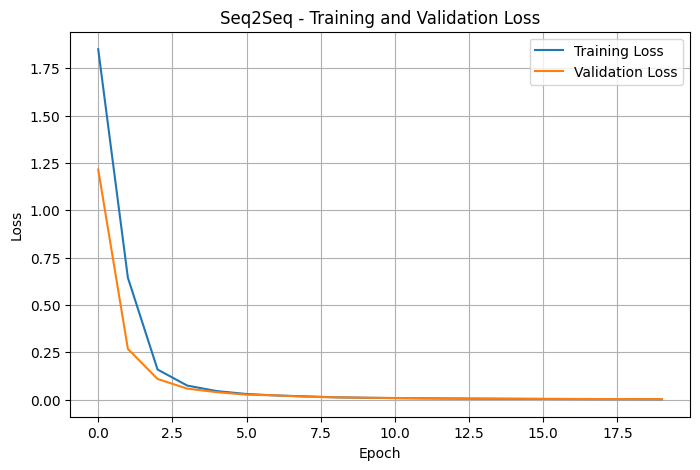

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    seq2seq_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    seq2seq_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# -----------------------------
# Encoder inference model
# -----------------------------

encoder_model = Model(
    encoder_inputs,
    [state_h, state_c]
)


# -----------------------------
# Decoder inference model
# -----------------------------
decoder_state_h = Input(
    shape=(SEQ_UNITS,)
)

decoder_state_c = Input(
    shape=(SEQ_UNITS,)
)

decoder_single_input = Input(
    shape=(1,)
)

decoder_single_embedding = decoder_embedding_layer(
    decoder_single_input
)

decoder_single_output, new_h, new_c = decoder_lstm(
    decoder_single_embedding,
    initial_state=[
        decoder_state_h,
        decoder_state_c
    ]
)

decoder_single_output = decoder_dense(
    decoder_single_output
)

decoder_model = Model(
    [
        decoder_single_input,
        decoder_state_h,
        decoder_state_c
    ],
    [
        decoder_single_output,
        new_h,
        new_c
    ]
)

print("Inference models created successfully.")

Inference models created successfully.


In [10]:
def decode_sequence(input_sequence):
    
    # Encode input sequence
    state_h, state_c = encoder_model.predict(
        input_sequence[np.newaxis, :],
        verbose=0
    )

    # Start with START_TOKEN = 0
    current_token = np.array([[START_TOKEN]])
    predicted_sequence = []
    
    for _ in range(SEQ_LEN):
        output, state_h, state_c = decoder_model.predict(
            [
                current_token,
                state_h,
                state_c
            ],
            verbose=0
        )

        predicted_token = np.argmax(
            output[0, 0, :]
        )

        predicted_sequence.append(
            predicted_token
        )

        current_token = np.array(
            [[predicted_token]]
        )

    return np.array(predicted_sequence)


# Generate predictions for the test set
seq2seq_predictions = []
for i in range(len(X_seq_test)):
    prediction = decode_sequence(
        X_seq_test[i]
    )
    seq2seq_predictions.append(prediction)

seq2seq_predictions = np.array(
    seq2seq_predictions
)


# -----------------------------
# Token accuracy
# -----------------------------
token_accuracy = np.mean(
    seq2seq_predictions == y_seq_test
)


# -----------------------------
# Sequence accuracy
# -----------------------------
sequence_accuracy = np.mean(
    np.all(
        seq2seq_predictions == y_seq_test,
        axis=1
    )
)

print("Token Accuracy   :", token_accuracy * 100, "%")
print("Sequence Accuracy:", sequence_accuracy * 100, "%")

Token Accuracy   : 100.0 %
Sequence Accuracy: 100.0 %


In [11]:
print("Five Seq2Seq Test Examples")
print("=" * 50)

for i in range(5):
    
    print("Sample", i + 1)
    print("Input     :", X_seq_test[i])
    print("Predicted :", seq2seq_predictions[i])
    print("Actual    :", y_seq_test[i])
    print()

Five Seq2Seq Test Examples
Sample 1
Input     : [2 3 4 7]
Predicted : [7 4 3 2]
Actual    : [7 4 3 2]

Sample 2
Input     : [5 2 3 6]
Predicted : [6 3 2 5]
Actual    : [6 3 2 5]

Sample 3
Input     : [8 4 8 1]
Predicted : [1 8 4 8]
Actual    : [1 8 4 8]

Sample 4
Input     : [1 5 2 4]
Predicted : [4 2 5 1]
Actual    : [4 2 5 1]

Sample 5
Input     : [3 6 3 2]
Predicted : [2 3 6 3]
Actual    : [2 3 6 3]



##Additionl Exercise 7

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3638 - loss: 1.8829 - val_accuracy: 0.4751 - val_loss: 1.3174
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7490 - loss: 0.7891 - val_accuracy: 0.9600 - val_loss: 0.3302
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9923 - loss: 0.1698 - val_accuracy: 0.9996 - val_loss: 0.0929
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0608 - val_accuracy: 1.0000 - val_loss: 0.0450
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0322 - val_accuracy: 1.0000 - val_loss: 0.0263
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0205 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0144 - val_accuracy: 1.0000 - val_loss: 0.0133
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 1

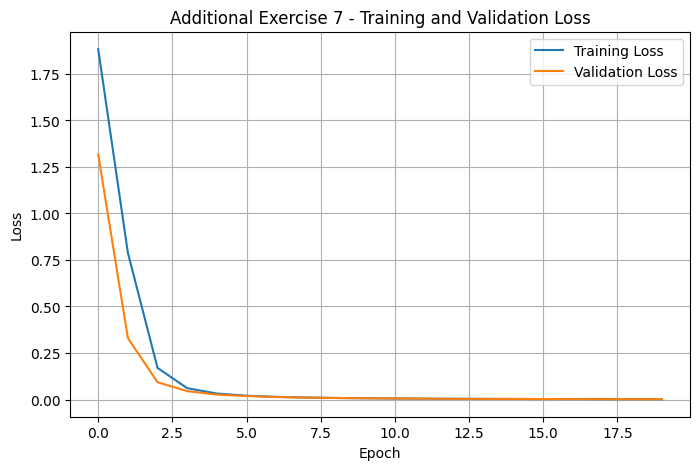

In [12]:
# Additional Exercise 7
# Different input and output sequence lengths

INPUT_LEN = 4
OUTPUT_LEN = 3
NUM_SAMPLES = 5000

np.random.seed(42)

# Input: 4 elements
X_diff = np.random.randint(
    1, VOCAB_SIZE + 1,
    (NUM_SAMPLES, INPUT_LEN)
)

# Output: reversed sequence, but only 3 elements
y_diff = np.flip(X_diff, axis=1)[:, :OUTPUT_LEN]

# Train / validation / test split
X_diff_train, X_temp, y_diff_train, y_temp = train_test_split(
    X_diff, y_diff,
    test_size=0.30,
    random_state=42
)

X_diff_val, X_diff_test, y_diff_val, y_diff_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Decoder input
decoder_diff_train = create_decoder_input(y_diff_train)
decoder_diff_val = create_decoder_input(y_diff_val)

# Encoder
enc_in = Input(shape=(INPUT_LEN,))
enc_emb = Embedding(VOCAB_SIZE + 1, SEQ_UNITS)(enc_in)

_, h, c = LSTM(
    SEQ_UNITS,
    return_state=True
)(enc_emb)

# Decoder
dec_in = Input(shape=(OUTPUT_LEN,))
dec_emb = Embedding(VOCAB_SIZE + 1, SEQ_UNITS)(dec_in)

dec_out = LSTM(
    SEQ_UNITS,
    return_sequences=True
)(
    dec_emb,
    initial_state=[h, c]
)

dec_out = Dense(
    VOCAB_SIZE + 1,
    activation="softmax"
)(dec_out)

# Model
diff_model = Model(
    [enc_in, dec_in],
    dec_out
)

diff_model.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
diff_history = diff_model.fit(
    [X_diff_train, decoder_diff_train],
    y_diff_train[..., np.newaxis],
    validation_data=(
        [X_diff_val, decoder_diff_val],
        y_diff_val[..., np.newaxis]
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Results
print("Input shape :", X_diff.shape)
print("Output shape:", y_diff.shape)

print("\nExample:")
print("Input :", X_diff[0])
print("Output:", y_diff[0])

# Loss plot
plt.figure(figsize=(8, 5))

plt.plot(
    diff_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    diff_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Additional Exercise 7 - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

##Additional Exercises -1

In [72]:
def build_model_units(recurrent_type, units, sequence_length=128):
    model = Sequential()

    if recurrent_type == "RNN":
        model.add(SimpleRNN(units, input_shape=(sequence_length, 9)))
    elif recurrent_type == "LSTM":
        model.add(LSTM(units, input_shape=(sequence_length, 9)))
    elif recurrent_type == "GRU":
        model.add(GRU(units, input_shape=(sequence_length, 9)))

    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(6, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [73]:
unit_results = []

for units in [16, 64]:
    for model_name in ["RNN", "LSTM", "GRU"]:

        print("\n", model_name, "-", units, "units")

        model = build_model_units(model_name, units)

        start_time = time.time()

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=32,
            verbose=0
        )

        training_time = time.time() - start_time

        probabilities = model.predict(X_test, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        accuracy = accuracy_score(y_test, predictions)
        f1 = f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )

        unit_results.append({
            "Model": model_name,
            "Units": units,
            "Accuracy (%)": accuracy * 100,
            "Macro F1 (%)": f1 * 100,
            "Parameters": model.count_params(),
            "Training Time (s)": training_time
        })

unit_results_df = pd.DataFrame(unit_results)
display(unit_results_df)


 RNN - 16 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 LSTM - 16 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 GRU - 16 units


...


 LSTM - 64 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 GRU - 64 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Model,Units,Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,16,71.111111,70.974445,790,26.144068
1,LSTM,16,94.000000,93.931336,2038,20.982099
2,GRU,16,94.444444,94.410657,1670,21.670482
3,RNN,64,83.111111,83.144198,5878,27.452728
4,LSTM,64,96.000000,96.000000,20086,21.795233
5,GRU,64,94.888889,94.858780,15542,21.088815


#Additional 3

In [74]:
two_lstm_model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(128, 9)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

two_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

two_lstm_history = two_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

two_lstm_time = time.time() - start_time

two_lstm_prob = two_lstm_model.predict(X_test, verbose=0)
two_lstm_pred = np.argmax(two_lstm_prob, axis=1)

two_lstm_accuracy = accuracy_score(y_test, two_lstm_pred)
two_lstm_f1 = f1_score(
    y_test,
    two_lstm_pred,
    average="macro",
    zero_division=0
)

print("Accuracy:", two_lstm_accuracy * 100)
print("Macro F1:", two_lstm_f1 * 100)
print("Parameters:", two_lstm_model.count_params())
print("Training time:", two_lstm_time)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4605 - loss: 1.4695 - val_accuracy: 0.5956 - val_loss: 1.1823
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6919 - loss: 0.8338 - val_accuracy: 0.7089 - val_loss: 0.8198
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8281 - loss: 0.4945 - val_accuracy: 0.9156 - val_loss: 0.3406
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9205 - loss: 0.2920 - val_accuracy: 0.9111 - val_loss: 0.2402
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9424 - loss: 0.2016 - val_accuracy: 0.9378 - val_loss: 0.1991
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9476 - loss: 0.1722 - val_accuracy: 0.9400 - val_loss: 0.1609
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9548 - loss: 0.1441 - val_accuracy: 0.9378 - val_loss: 0.1575
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9562 - loss: 0.1355 - val_accuracy: 0.9467 - val_loss: 0.

##Additional 4

In [75]:
from tensorflow.keras.layers import Bidirectional
bi_lstm_model = Sequential([
    Bidirectional(LSTM(32), input_shape=(128, 9)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

bi_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

bi_lstm_history = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

bi_lstm_time = time.time() - start_time

bi_lstm_prob = bi_lstm_model.predict(X_test, verbose=0)
bi_lstm_pred = np.argmax(bi_lstm_prob, axis=1)

bi_lstm_accuracy = accuracy_score(y_test, bi_lstm_pred)
bi_lstm_f1 = f1_score(
    y_test,
    bi_lstm_pred,
    average="macro",
    zero_division=0
)

print("Accuracy:", bi_lstm_accuracy * 100)
print("Macro F1:", bi_lstm_f1 * 100)
print("Parameters:", bi_lstm_model.count_params())
print("Training time:", bi_lstm_time)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5043 - loss: 1.4170 - val_accuracy: 0.5644 - val_loss: 1.0061
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7119 - loss: 0.7288 - val_accuracy: 0.7889 - val_loss: 0.5157
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7905 - loss: 0.5051 - val_accuracy: 0.7933 - val_loss: 0.4088
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8424 - loss: 0.3742 - val_accuracy: 0.8400 - val_loss: 0.3768
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8786 - loss: 0.3280 - val_accuracy: 0.8933 - val_loss: 0.3175
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9171 - loss: 0.2513 - val_accuracy: 0.9244 - val_loss: 0.2161
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9043 - loss: 0.2732 - val_accuracy: 0.9289 - val_loss: 0.2124
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9414 - loss: 0.1684 - val_accuracy: 0.9311 - val_loss: 0.

##Additional 6

In [76]:
video_gru_model = Sequential([
    GRU(32, input_shape=(NUM_FRAMES, X_video_train.shape[2])),
    Dense(len(CLASS_NAMES), activation="softmax")
])

video_gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

video_gru_history = video_gru_model.fit(
    X_video_train,
    y_video_train,
    validation_data=(X_video_val, y_video_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

video_gru_time = time.time() - start_time

video_gru_prob = video_gru_model.predict(X_video_test, verbose=0)
video_gru_pred = np.argmax(video_gru_prob, axis=1)

video_gru_accuracy = accuracy_score(
    y_video_test,
    video_gru_pred
)

video_gru_f1 = f1_score(
    y_video_test,
    video_gru_pred,
    average="macro",
    zero_division=0
)

print("CNN-GRU Accuracy:", video_gru_accuracy * 100)
print("CNN-GRU Macro F1:", video_gru_f1 * 100)
print("Parameters:", video_gru_model.count_params())
print("Training time:", video_gru_time)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6333 - loss: 0.9664 - val_accuracy: 0.8235 - val_loss: 0.5921
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9667 - loss: 0.2438 - val_accuracy: 0.8627 - val_loss: 0.4014
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0844 - val_accuracy: 0.8431 - val_loss: 0.3552
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 0.8627 - val_loss: 0.2953
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy: 0.8627 - val_loss: 0.3137
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 0.8627 - val_loss: 0.3237
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.8627 - val_loss: 0.3045
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0114 - val_accuracy: 0.8627 - val_loss: 0.2858
Epoch 9/30
